In [1]:
# Regression Diagnostics

This notebook evaluates whether the main regression results are driven by a small number of influential Members of the European Parliament (MEPs).

Rather than estimating new substantive models, the notebook reproduces the main regression specification and applies standard regression diagnostics.

The diagnostics implemented are:

1. DFBETA
2. Cook's Distance
3. Leverage (Hat Values)

These diagnostics are commonly used as robustness checks in applied economics and political science.

## Workflow

1. Load cleaned analysis dataset
2. Estimate the main OLS model
3. Compute DFBETA
4. Compute Cook's Distance
5. Compute leverage
6. Identify influential observations
7. Export figures and tables

SyntaxError: unterminated string literal (detected at line 10) (1806391139.py, line 10)

In [2]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

# ----------------------------------------------------------
# Project paths
# ----------------------------------------------------------

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from src.config import PROJECT_ROOT, ensure_default_directories

ensure_default_directories()

DIAGNOSTICS_DIR = PROJECT_ROOT / "8 Regression Diagnostics"

FINAL_ANALYSIS_DIR = PROJECT_ROOT / "7 Final Analysis"

OUTPUTS_DIR = DIAGNOSTICS_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

for folder in [OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ANALYSIS_DATA_PATH = (
    FINAL_ANALYSIS_DIR
    / "outputs"
    / "tables"
    / "polarisation_with_demography.xlsx"
)

analysis_df = pd.read_excel(ANALYSIS_DATA_PATH)

print("Rows:", len(analysis_df))
print("Columns:", len(analysis_df.columns))

Rows: 193
Columns: 103


In [ ]:
## Main Regression

The regression below reproduces the main specification used in the paper.

The fitted model is used only for diagnostic purposes.

In [12]:
outcome = "polarisation_score"

predictors = [

    "ep_group_clean",

    "gender_bucket",

    "education_level_bucket",

    "professional_background_clean",

    "region_clean",

]

predictors = [p for p in predictors if p in analysis_df.columns]

reg_df = analysis_df[
    ["mep_name_clean", outcome] + predictors
].copy()

reg_df = reg_df.dropna()

X = pd.get_dummies(
    reg_df[predictors],
    drop_first=True,
    dtype=float
)

X = sm.add_constant(X)

y = reg_df[outcome]

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     polarisation_score   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     1.906
Date:                Sun, 05 Jul 2026   Prob (F-statistic):            0.00386
Time:                        12:28:29   Log-Likelihood:                -390.31
No. Observations:                 189   AIC:                             854.6
Df Residuals:                     152   BIC:                             974.6
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [ ]:
## DFBETA Analysis

DFBETA measures how much each individual observation changes each estimated regression coefficient.

For every MEP, DFBETA asks:

> How much would the estimated coefficient change if this MEP were removed from the regression?

Large absolute DFBETA values indicate influential observations.

A commonly used threshold is

\[
\frac{2}{\sqrt{n}}
\]

where \(n\) is the number of observations.

In [5]:
# ----------------------------------------------------------
# DFBETA
# ----------------------------------------------------------

influence = OLSInfluence(ols_model)

dfbeta = pd.DataFrame(
    influence.dfbetas,
    columns=X.columns,
    index=reg_df.index,
)

threshold = 2 / np.sqrt(len(reg_df))

print(f"Number of observations: {len(reg_df)}")
print(f"Suggested DFBETA threshold: ±{threshold:.3f}")

Number of observations: 189
Suggested DFBETA threshold: ±0.145


In [6]:
# ----------------------------------------------------------
# Largest DFBETAs
# ----------------------------------------------------------

rows = []

for coefficient in dfbeta.columns:

    temp = pd.DataFrame({

        "MEP": analysis_df.loc[dfbeta.index, "mep_name_clean"],

        "Coefficient": coefficient,

        "DFBETA": dfbeta[coefficient],

        "Absolute DFBETA": dfbeta[coefficient].abs()

    })

    rows.append(temp)

largest_dfbeta = (
    pd.concat(rows)
      .sort_values("Absolute DFBETA", ascending=False)
)

display(largest_dfbeta.head(25))

,MEP,Coefficient,DFBETA,Absolute DFBETA
133,mireille d ornano,"ep_group_clean_NI, ENL, ELDD",2.588261,2.588261
87,jean paul garraud,ep_group_clean_PfE,2.425877,2.425877
50,dominique bilde,ep_group_clean_ID (Identité et démocratie),2.016881,2.016881
26,bruno gollnisch,ep_group_clean_Non-Inscrits,1.464894,1.464894
151,philippe olivier,professional_background_clean_Law,1.256238,1.256238
120,maria lidia senra rodriguez,professional_background_clean_Other / Specialist,0.931063,0.931063
179,tineke strik,ep_group_clean_Greens–European Free Alliance,0.930416,0.930416
92,johan van overtveldt,ep_group_clean_EPP,0.900177,0.900177
92,johan van overtveldt,ep_group_clean_S&D,0.891867,0.891867
92,johan van overtveldt,ep_group_clean_Unknown,0.888713,0.888713


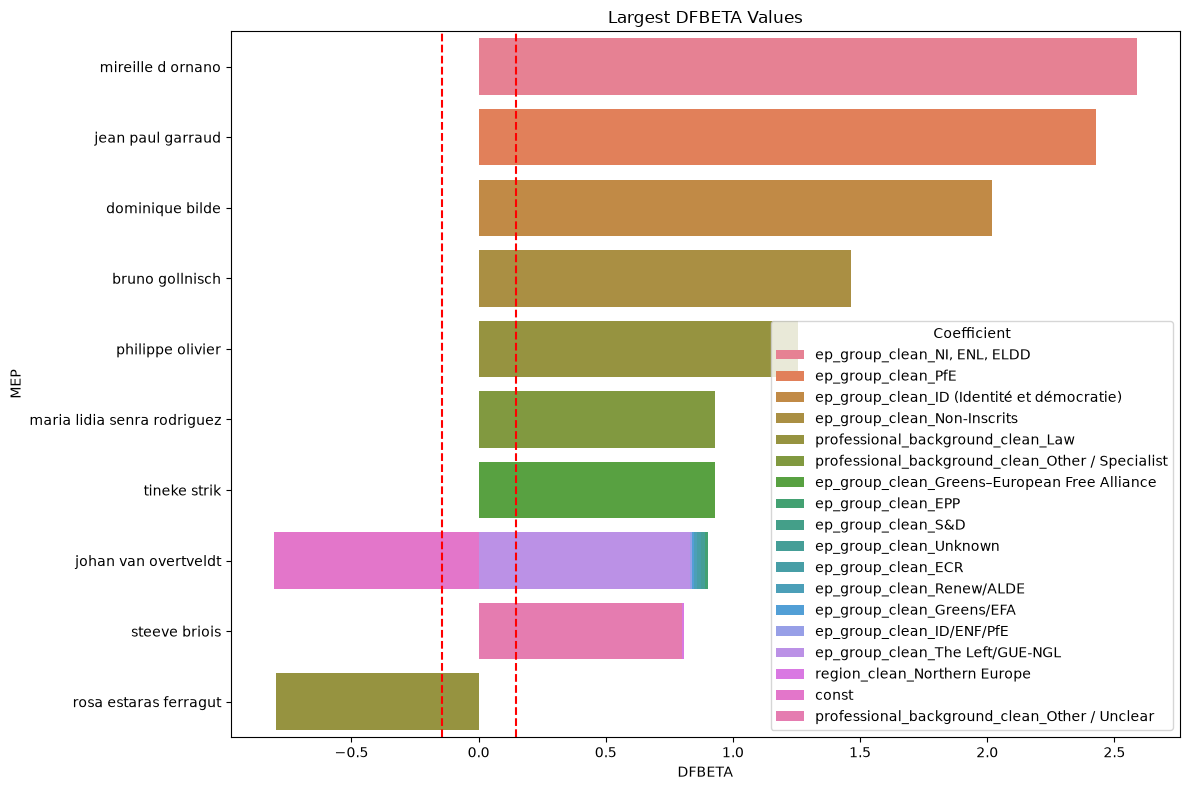

In [7]:
# ----------------------------------------------------------
# Plot largest DFBETAs
# ----------------------------------------------------------

top = largest_dfbeta.head(20).copy()

plt.figure(figsize=(12,8))

sns.barplot(

    data=top,

    y="MEP",

    x="DFBETA",

    hue="Coefficient",

    dodge=False

)

plt.axvline(threshold,
            color="red",
            linestyle="--")

plt.axvline(-threshold,
            color="red",
            linestyle="--")

plt.title("Largest DFBETA Values")

plt.xlabel("DFBETA")

plt.ylabel("MEP")

plt.tight_layout()

plt.show()

In [ ]:
## Summary of Influential MEPs

Rather than examining individual regression coefficients separately, this section summarizes the overall influence of each Member of the European Parliament.

For every MEP we calculate:

- Maximum absolute DFBETA
- Number of regression coefficients whose DFBETA exceeds the conventional threshold

This provides a concise overview of which politicians exert the greatest influence on the regression results.

In [9]:
# ----------------------------------------------------------
# Summarise influence by MEP
# ----------------------------------------------------------

mep_influence = pd.DataFrame({

    "MEP": analysis_df.loc[dfbeta.index, "mep_name_clean"]

})

mep_influence["Maximum |DFBETA|"] = dfbeta.abs().max(axis=1)

mep_influence["Coefficients above threshold"] = (
    (dfbeta.abs() > threshold)
    .sum(axis=1)
)

mep_influence = (
    mep_influence
    .sort_values(
        "Maximum |DFBETA|",
        ascending=False
    )
    .reset_index(drop=True)
)

display(mep_influence.head(20))

,MEP,Maximum |DFBETA|,Coefficients above threshold
0,mireille d ornano,2.588261,1
1,jean paul garraud,2.425877,1
2,dominique bilde,2.016881,1
3,bruno gollnisch,1.464894,1
4,philippe olivier,1.256238,6
5,maria lidia senra rodriguez,0.931063,4
6,tineke strik,0.930416,8
7,johan van overtveldt,0.900177,23
8,steeve briois,0.805601,5
9,rosa estaras ferragut,0.798112,3


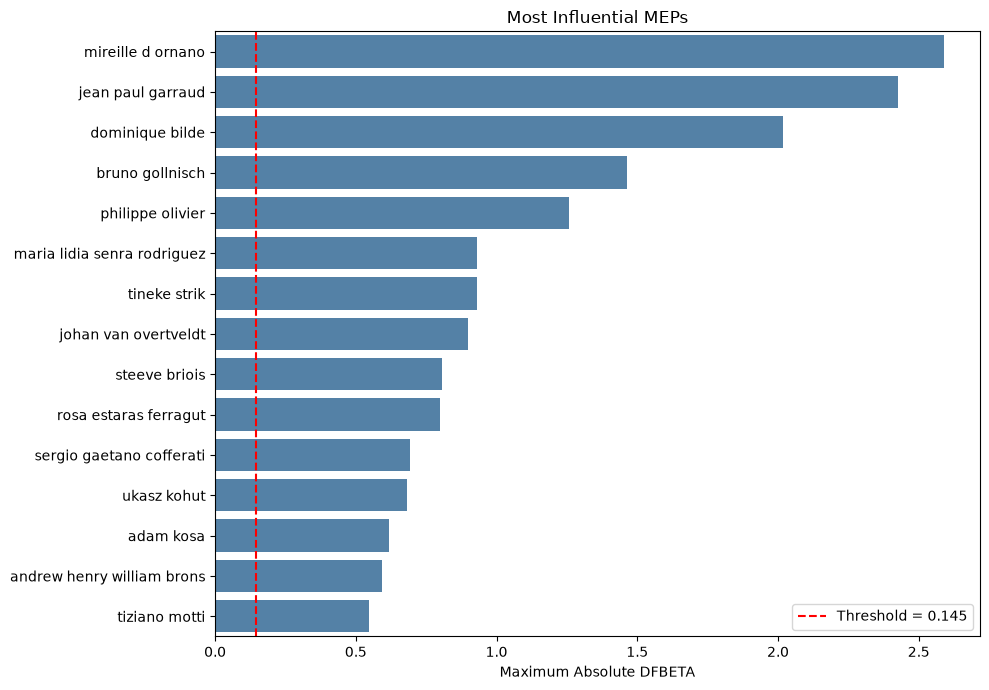

In [10]:
# ----------------------------------------------------------
# Plot influential MEPs
# ----------------------------------------------------------

top = mep_influence.head(15)

plt.figure(figsize=(10,7))

sns.barplot(

    data=top,

    y="MEP",

    x="Maximum |DFBETA|",

    color="steelblue"

)

plt.axvline(

    threshold,

    color="red",

    linestyle="--",

    label=f"Threshold = {threshold:.3f}"

)

plt.title("Most Influential MEPs")

plt.xlabel("Maximum Absolute DFBETA")

plt.ylabel("")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
## Cook's Distance

Cook's Distance measures the overall influence of each observation on the fitted regression model.

Unlike DFBETA, which evaluates influence on individual regression coefficients, Cook's Distance summarizes the influence of each observation on the model as a whole.

Observations with larger Cook's Distance values deserve closer inspection because they may disproportionately affect the estimated regression results.

As a rule of thumb, observations with

\[
D_i > \frac{4}{n}
\]

are often considered influential.

In [13]:
# ----------------------------------------------------------
# Cook's Distance
# ----------------------------------------------------------

cook = influence.cooks_distance[0]

cook_df = pd.DataFrame({

    "MEP": reg_df["mep_name_clean"].values,

    "Cook's Distance": cook

})

cook_df = cook_df.sort_values(
    "Cook's Distance",
    ascending=False
).reset_index(drop=True)

cook_threshold = 4 / len(reg_df)

print(f"Cook's Distance threshold: {cook_threshold:.4f}")

display(cook_df.head(20))

Cook's Distance threshold: 0.0212


,MEP,Cook's Distance
0,mireille d ornano,1.528129
1,johan van overtveldt,0.900992
2,dominique bilde,0.748783
3,tineke strik,0.102138
4,laura ferrara,0.095508
5,steeve briois,0.073708
6,maria lidia senra rodriguez,0.064327
7,philippe olivier,0.063610
8,angelo ciocca,0.041823
9,ukasz kohut,0.036791


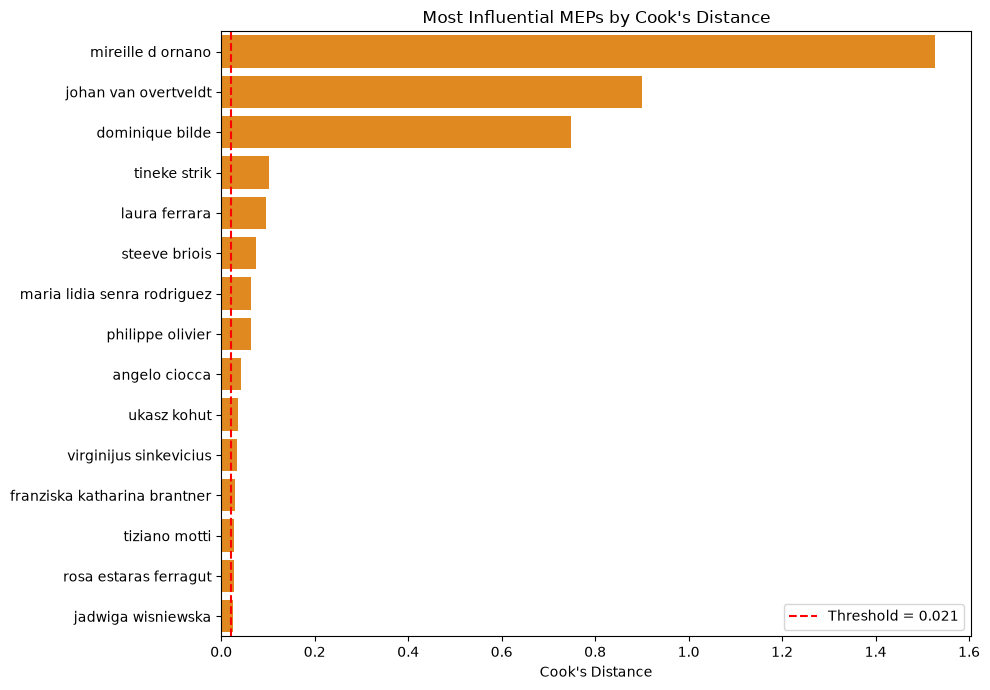

In [14]:
# ----------------------------------------------------------
# Plot Cook's Distance
# ----------------------------------------------------------

top = cook_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(

    data=top,

    y="MEP",

    x="Cook's Distance",

    color="darkorange"

)

plt.axvline(

    cook_threshold,

    color="red",

    linestyle="--",

    label=f"Threshold = {cook_threshold:.3f}"

)

plt.title("Most Influential MEPs by Cook's Distance")

plt.xlabel("Cook's Distance")

plt.ylabel("")

plt.legend()

plt.tight_layout()

plt.show()

## Leverage (Hat Values)

Leverage measures how unusual an observation is in terms of its predictor values.

An observation with high leverage has characteristics that differ substantially from the rest of the sample and therefore has greater potential to influence the fitted regression model.

A common rule of thumb identifies high-leverage observations as those with

\[
h_i > \frac{2(p+1)}{n}
\]

where:

- \(p\) is the number of explanatory variables (excluding the intercept),
- \(n\) is the sample size.

In [15]:
# ----------------------------------------------------------
# Leverage (Hat Values)
# ----------------------------------------------------------

leverage = influence.hat_matrix_diag

leverage_df = pd.DataFrame({

    "MEP": reg_df["mep_name_clean"].values,

    "Leverage": leverage

})

leverage_df = (
    leverage_df
    .sort_values("Leverage", ascending=False)
    .reset_index(drop=True)
)

p = X.shape[1] - 1        # number of predictors (excluding intercept)

n = len(reg_df)

leverage_threshold = 2 * (p + 1) / n

print(f"Leverage threshold: {leverage_threshold:.3f}")

display(leverage_df.head(20))

Leverage threshold: 0.392


,MEP,Leverage
0,claudio morganti,1.000000
1,tiziana beghin,1.000000
2,bruno gollnisch,1.000000
3,angelika werthmann,1.000000
4,jean paul garraud,1.000000
5,isabella tovaglieri,1.000000
6,antonio cancian,1.000000
7,mireille d ornano,1.000000
8,laura ferrara,1.000000
9,dominique bilde,1.000000


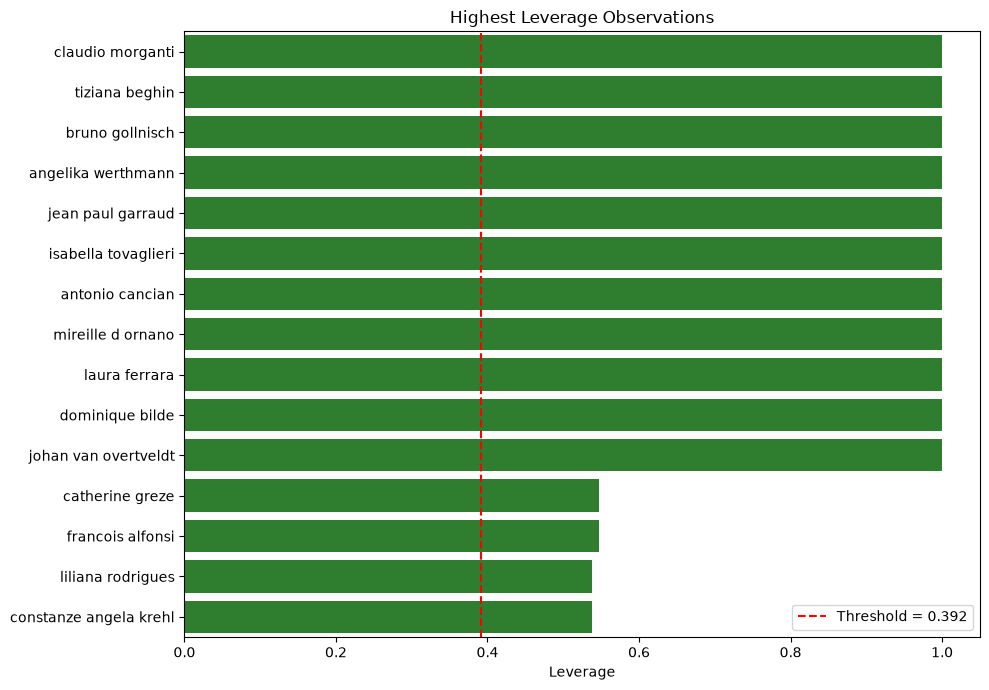

In [16]:
# ----------------------------------------------------------
# Plot Leverage
# ----------------------------------------------------------

top = leverage_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(

    data=top,

    y="MEP",

    x="Leverage",

    color="forestgreen"

)

plt.axvline(

    leverage_threshold,

    color="red",

    linestyle="--",

    label=f"Threshold = {leverage_threshold:.3f}"

)

plt.title("Highest Leverage Observations")

plt.xlabel("Leverage")

plt.ylabel("")

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
# ----------------------------------------------------------
# Regression diagnostics summary
# ----------------------------------------------------------

summary_df = pd.DataFrame({

    "MEP": reg_df["mep_name_clean"].values,

    "Max |DFBETA|": dfbeta.abs().max(axis=1),

    "Cook's Distance": cook,

    "Leverage": leverage,

})

summary_df["DFBETA > threshold"] = (
    summary_df["Max |DFBETA|"] > threshold
)

summary_df["Cook > threshold"] = (
    summary_df["Cook's Distance"] > cook_threshold
)

summary_df["High leverage"] = (
    summary_df["Leverage"] > leverage_threshold
)

summary_df = summary_df.sort_values(

    "Max |DFBETA|",

    ascending=False

)

display(summary_df.head(20))

,MEP,Max |DFBETA|,Cook's Distance,Leverage,DFBETA > threshold,Cook > threshold,High leverage
133,mireille d ornano,2.588261,1.528129,1.000000,True,True,True
87,jean paul garraud,2.425877,NaN,1.000000,True,False,True
50,dominique bilde,2.016881,0.748783,1.000000,True,True,True
26,bruno gollnisch,1.464894,NaN,1.000000,True,False,True
151,philippe olivier,1.256238,0.063610,0.309561,True,True,False
120,maria lidia senra rodriguez,0.931063,0.064327,0.460240,True,True,True
179,tineke strik,0.930416,0.102138,0.359118,True,True,False
92,johan van overtveldt,0.900177,0.900992,1.000000,True,True,True
171,steeve briois,0.805601,0.073708,0.258503,True,True,False
160,rosa estaras ferragut,0.798112,0.026920,0.299258,True,True,False


In [18]:
summary_df.to_excel(
    TABLES_DIR / "regression_diagnostics_summary.xlsx",
    index=False
)

print("Regression diagnostics summary exported.")

Regression diagnostics summary exported.
